In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns

mo_county_covid_econ_2022 = pd.read_csv('missouri_counties_covid_and_economic_data_2022.csv')
mo_county_covid_econ_2022

,County,County FIPS Code,2022 Covid Infections,2022 Covid Deaths,2022 Population Estimate,2022 Real GDP,Average Household Income,Covid Infections Per Capita,Covid Deaths Per Capita
0,ST LOUIS,29189.0,124171,358,991881,89147507,81340,0.125187,0.000361
1,JACKSON,29095.0,79621,207,716580,50118029,67178,0.111113,0.000289
2,ST CHARLES,29183.0,48803,49,414055,19607818,102912,0.117866,0.000118
3,GREENE,29077.0,33739,75,303336,18163171,57488,0.111226,0.000247
4,ST LOUIS CITY,29510.0,32679,31,286292,31193060,55279,0.114146,0.000108
5,CLAY,29047.0,28200,48,257037,13662294,86150,0.109712,0.000187
6,JEFFERSON,29099.0,26023,62,229268,5241427,80522,0.113505,0.000270
7,BOONE,29019.0,23705,0,187743,9997270,69913,0.126263,0.000000
8,JASPER,29097.0,14283,31,123969,5475966,57525,0.115214,0.000250
9,CASS,29037.0,11391,14,110345,2962114,87413,0.103231,0.000127


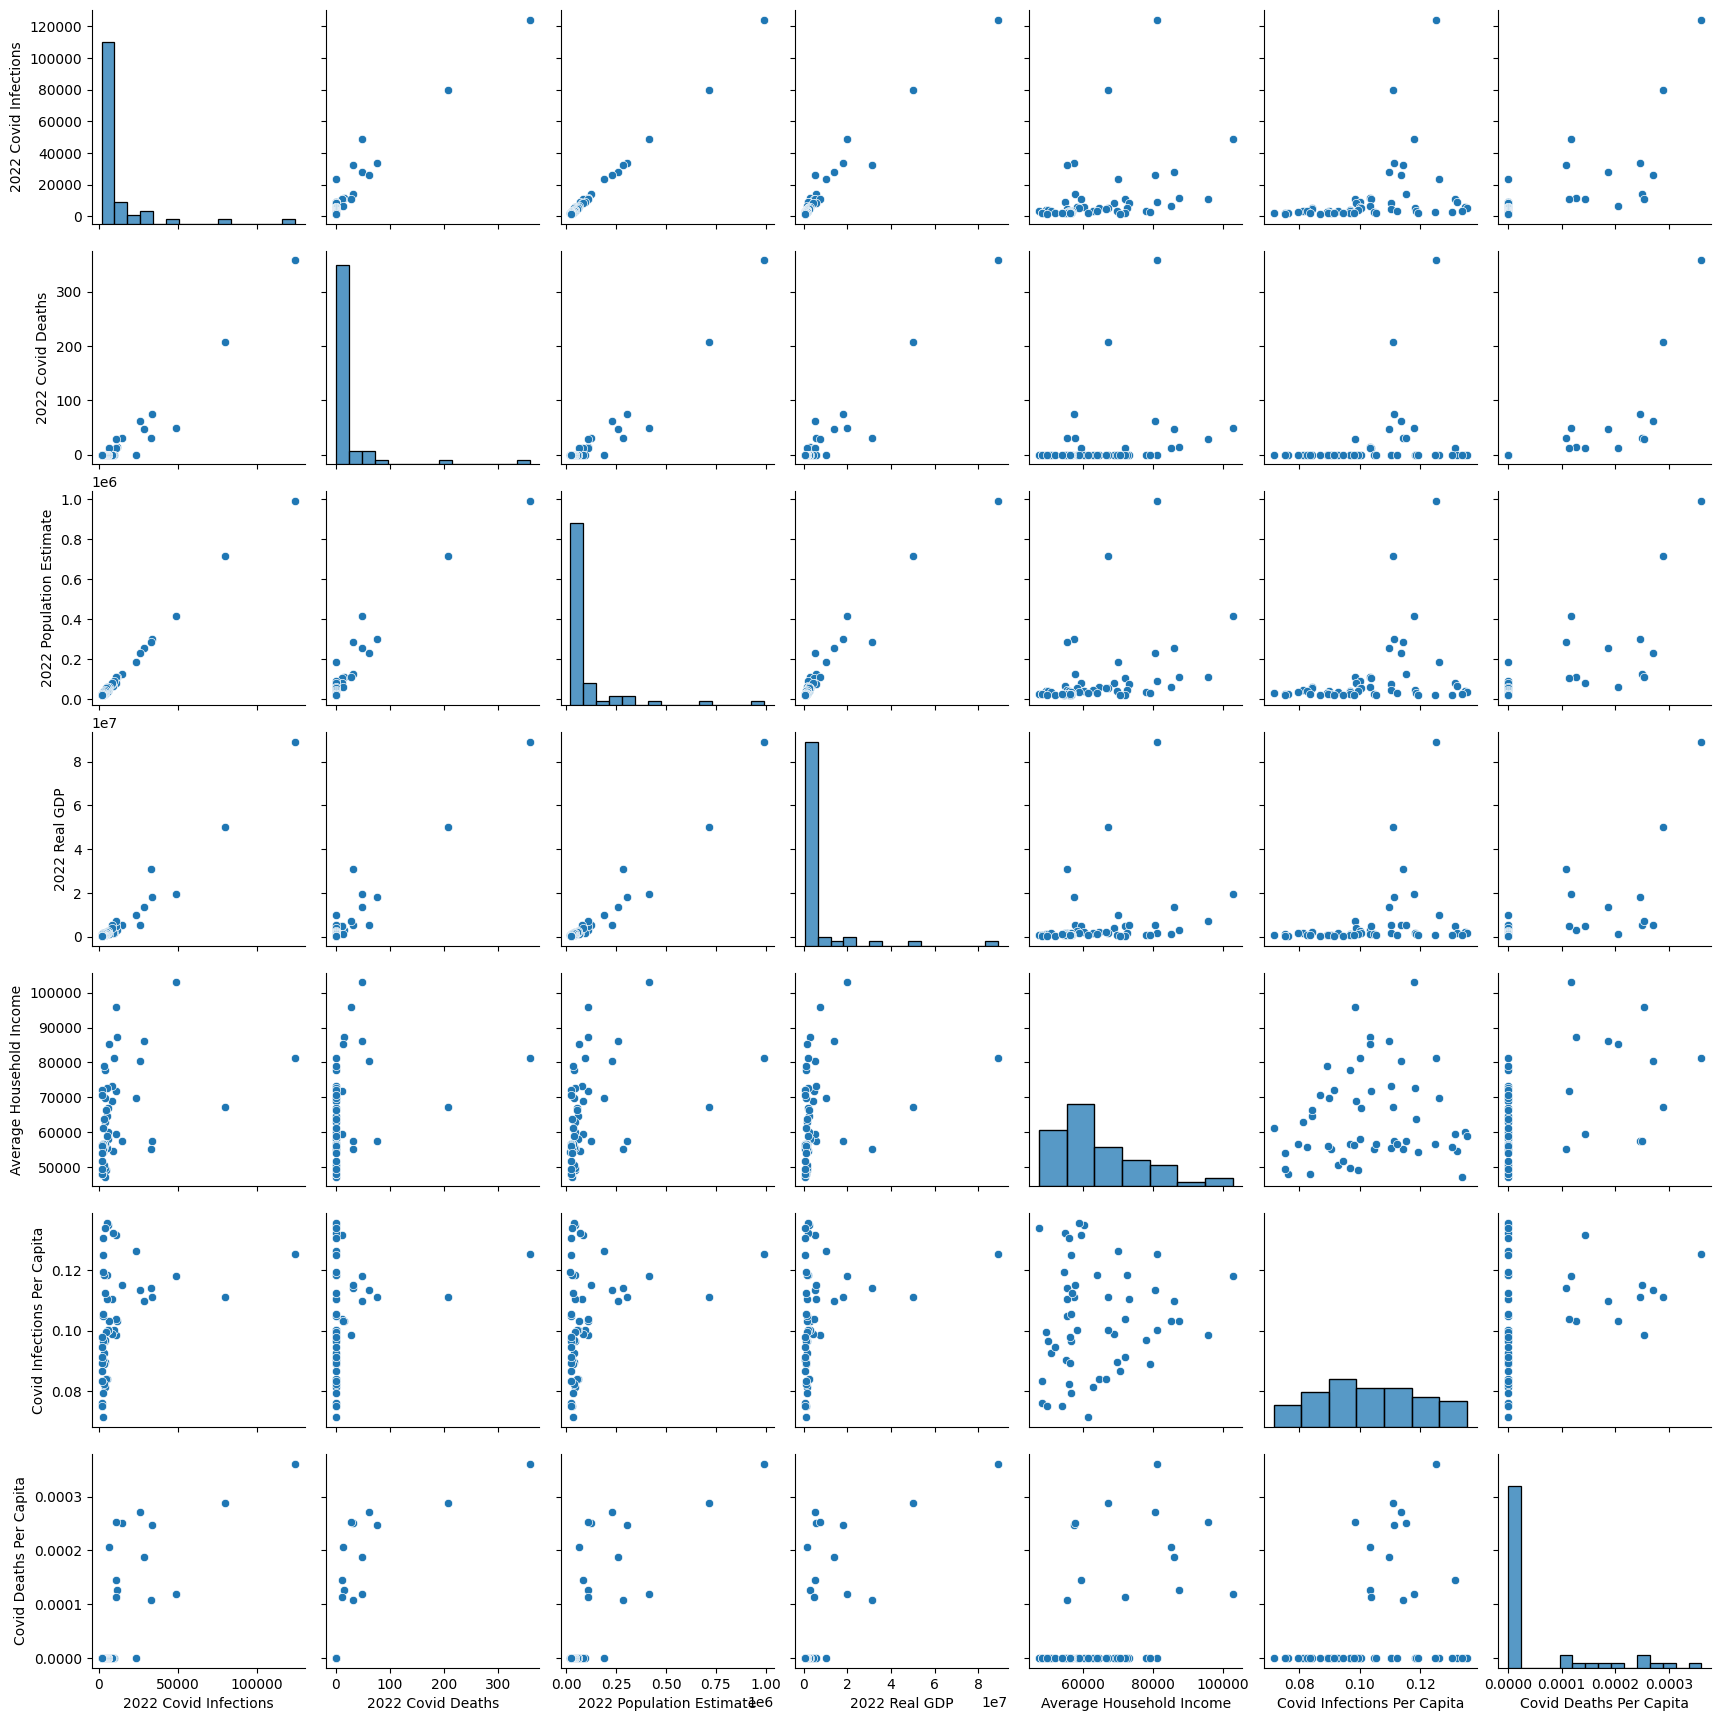

In [2]:
sns.pairplot(mo_county_covid_econ_2022.drop(columns=['County FIPS Code']))

In [3]:
corr_matrix = mo_county_covid_econ_2022.drop(columns=['County FIPS Code']).corr(numeric_only=True)


<Axes: >

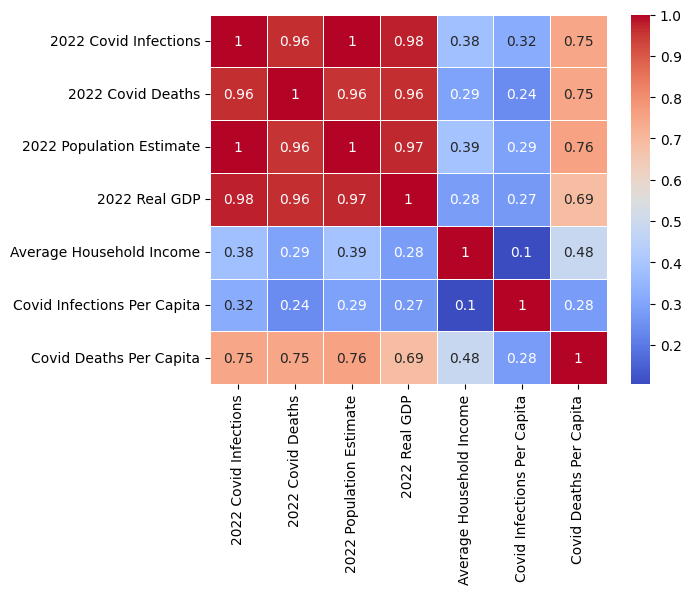

In [4]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)  

(possible confounding variables problem or multicollinearity problem)
The highly correlated block of features is not good because it muddles with what we know about each individual feature correlation to covid deaths per capita and covid infections per capita because we don't know which feature is actually responsible for the correlation. For example: is GDP correlated with infections and deaths per caita because it directly increase them? Or is it because gdp increases with population, and its actually population that causes more infections and deaths per capita and gdp just comes along for the ride.

In [5]:
threshold = 0.7
print(f"Pairs with correlation > {threshold} or < -{threshold}:\n")

columns = corr_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            print(f"{columns[i]} & {columns[j]}: {corr_value:.2f}")

Pairs with correlation > 0.7 or < -0.7:

2022 Covid Infections & 2022 Covid Deaths: 0.96
2022 Covid Infections & 2022 Population Estimate: 1.00
2022 Covid Infections & 2022 Real GDP: 0.98
2022 Covid Infections & Covid Deaths Per Capita: 0.75
2022 Covid Deaths & 2022 Population Estimate: 0.96
2022 Covid Deaths & 2022 Real GDP: 0.96
2022 Covid Deaths & Covid Deaths Per Capita: 0.75
2022 Population Estimate & 2022 Real GDP: 0.97
2022 Population Estimate & Covid Deaths Per Capita: 0.76


Looking at the feature correlations we see that Covid Infections and Covid Deaths are highly correlated with Real GDP as well as Population. The problem is that Real GDP and Population are also highly correlated so the relationship between these variables are tangled. We do not see Covid Infections Per Capita in any relationship within this high correlation list. We also observe that only Population has a correlation with Covid Deaths Per Capita above the threshold, with Real GDP being absent. Firstly, this suggests that Population is not only correlated with Covid Deaths purely because "more poeple so more deaths" as it is also highly correlated with Covid Deaths Per Capita. This suggests that Covid Deaths is disproportionately higher when population increases. The absence of GDP in this high correlation list with Covid Deaths Per Capita suggests that population is a stronger driver for deaths and that GDP just tagged along with population even though they were both highly correlated with deaths. GDP might've dropped off because it was just tagging along with Population as when we got rid of the population size factor of Covid Deaths and converted it to Deaths per Capita it leveled the population playing field which GDP is highly dependent on.